# P-ML14 — Weekday-Only Strategy: Exploiting the Cross-Asset Signal

**Insight from P-ML13:** V3 (19f, +cross-asset) crushed V2 on business days
(scaled Sharpe +1.118 vs +0.656) but lost on 7-day data (+1.360 vs +1.583)
because forward-filled weekend features add noise.

**Idea:** What if we design a strategy that trades only Monday–Friday,
going flat at Friday close and re-entering Monday with fresh TradFi data?
This is how institutional crypto desks actually operate — they reduce
exposure over weekends due to thin liquidity.

**Three strategies to compare (all on the full 7-day BTC price series):**

| Strategy | Features | Weekend position |
|---|---|---|
| V2-24/7 (champion) | 16 BTC-only | Holds through weekends |
| V2-weekday | 16 BTC-only | Flat on weekends |
| V3-weekday | 19 BTC+cross-asset | Flat on weekends |

**Key question:** Does V3-weekday beat V2-24/7 *after accounting for the
opportunity cost of being flat on weekends*?

**Why this matters for production:**
- Institutional traders already reduce weekend exposure (liquidity, no TradFi hedging)
- Weekend BTC volatility is high but largely noise (no macro catalysts)
- Going flat on weekends is a natural risk reduction that may improve Sharpe

## §1 — Config & Data

In [1]:
import sys
from pathlib import Path
repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 9})

SYMBOL, SINCE, UNTIL = "BTC/USDT", "2019-01-01", "2025-01-01"
HORIZON, N_SPLITS, TRAIN_FRAC, PURGE = 1, 5, 0.6, 1
LONG_MA, ADX_THRESH, MIN_BULL_BARS = 200, 25.0, 30

FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]
CROSS_FEATURES = ["spy_btc_corr_30", "spy_ret_5", "vix_level_zscore"]
FEATURES_V3 = FEATURES_V2 + CROSS_FEATURES

PRED_ZSCORE_WINDOW, POSITION_SCALE, MAX_POSITION = 60, 0.5, 1.0

from data.fetch import fetch_ohlcv
from data.cross_asset import fetch_tradfi_ohlcv
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.features.cross_asset import build_cross_asset_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from backtesting import compute_metrics

# -- Load & build features -----------------------------------------------------
df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)
tradfi = {"SPY": fetch_tradfi_ohlcv("SPY", SINCE, UNTIL),
          "^VIX": fetch_tradfi_ohlcv("^VIX", SINCE, UNTIL)}

feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label_series = forward_return(df_raw, horizon=HORIZON)
LABEL_COL = label_series.name  # capture name before tz strip
rc  = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg = rc.transform(df_raw)

feats_cross_bizday = build_cross_asset_features(df_raw, tradfi)

# Strip tz
for s in [feats_base, feats_mom, label_series, reg]:
    if hasattr(s.index, 'tz') and s.index.tz is not None:
        s.index = s.index.tz_localize(None)

df_raw_naive = df_raw.copy()
df_raw_naive.index = df_raw_naive.index.normalize()
if df_raw_naive.index.tz is not None:
    df_raw_naive.index = df_raw_naive.index.tz_localize(None)
df_raw_naive = df_raw_naive[~df_raw_naive.index.duplicated(keep="last")]

btc_index_naive = df_raw_naive.index
feats_cross_7day = feats_cross_bizday.reindex(btc_index_naive, method="ffill")

# 7-day combined
comb_7d = pd.concat([feats_base, feats_mom, feats_cross_7day, label_series, reg["regime"]], axis=1).dropna()

bar_ret_7d = np.log(df_raw_naive["close"].reindex(comb_7d.index) /
                     df_raw_naive["close"].reindex(comb_7d.index).shift(1))

is_weekend = comb_7d.index.dayofweek >= 5

print(f"7-day dataset: {len(comb_7d):,} bars | weekdays: {(~is_weekend).sum():,} | weekends: {is_weekend.sum():,}")
print(f"Weekend fraction: {is_weekend.mean():.1%}")

7-day dataset: 2,132 bars | weekdays: 1,522 | weekends: 610
Weekend fraction: 28.6%


## §2 — Weekend Return Analysis

Before testing strategies, understand what we give up by being flat on weekends.

In [2]:
# -- Weekend vs weekday BTC return statistics ----------------------------------
wd_ret = bar_ret_7d[~is_weekend].dropna()
we_ret = bar_ret_7d[is_weekend].dropna()

print("BTC daily return statistics: weekday vs weekend")
print(f"{'Metric':<25} {'Weekday':>10} {'Weekend':>10} {'All':>10}")
print("-" * 58)
for label, wd, we, al in [
    ("N bars",             f"{len(wd_ret)}",   f"{len(we_ret)}",   f"{len(bar_ret_7d.dropna())}"),
    ("Mean return",        f"{wd_ret.mean()*100:+.3f}%", f"{we_ret.mean()*100:+.3f}%", f"{bar_ret_7d.dropna().mean()*100:+.3f}%"),
    ("Std return",         f"{wd_ret.std()*100:.3f}%",   f"{we_ret.std()*100:.3f}%",   f"{bar_ret_7d.dropna().std()*100:.3f}%"),
    ("Sharpe (annualised)",f"{wd_ret.mean()/wd_ret.std()*np.sqrt(365):+.3f}",
                           f"{we_ret.mean()/we_ret.std()*np.sqrt(365):+.3f}",
                           f"{bar_ret_7d.dropna().mean()/bar_ret_7d.dropna().std()*np.sqrt(365):+.3f}"),
    ("Cumulative return",  f"{np.exp(wd_ret.sum())-1:+.1%}", f"{np.exp(we_ret.sum())-1:+.1%}", f"{np.exp(bar_ret_7d.dropna().sum())-1:+.1%}"),
]:
    print(f"  {label:<23} {wd:>10} {we:>10} {al:>10}")

# Weekend return by era
print(f"\nWeekend mean return by year:")
for year in range(2019, 2025):
    mask = is_weekend & (comb_7d.index.year == year)
    r = bar_ret_7d[mask]
    if len(r) > 5:
        print(f"  {year}: mean={r.mean()*100:+.3f}%, std={r.std()*100:.3f}%, n={len(r)}")

BTC daily return statistics: weekday vs weekend
Metric                       Weekday    Weekend        All
----------------------------------------------------------
  N bars                        1522        609       2131
  Mean return                +0.178%    +0.081%    +0.150%
  Std return                  3.861%     2.419%     3.510%
  Sharpe (annualised)         +0.880     +0.639     +0.817
  Cumulative return         +1396.3%     +63.7%   +2349.0%

Weekend mean return by year:
  2019: mean=+0.234%, std=3.236%, n=88
  2020: mean=-0.067%, std=2.693%, n=104
  2021: mean=+0.180%, std=2.962%, n=104
  2022: mean=-0.240%, std=2.127%, n=105
  2023: mean=+0.263%, std=1.403%, n=105
  2024: mean=+0.143%, std=1.737%, n=104


## §3 — Walk-Forward: Three Strategies

All strategies use the same 7-day dataset and walk-forward splits.
The weekend mask is applied AFTER prediction, to the position signal only.

In [3]:
idx = comb_7d.index
X_v2 = comb_7d[FEATURES_V2]
X_v3 = comb_7d[FEATURES_V3]
y    = comb_7d[LABEL_COL]
regime = comb_7d["regime"].fillna("ranging")
splits = list(purged_wf_splits(len(comb_7d), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))


def run_wf(X, splits, y, regime):
    folds = []
    for i, (tr, te) in enumerate(splits):
        ens = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
        ens.fit(X.iloc[tr], y.iloc[tr], regime.iloc[tr])
        preds = ens.predict(X.iloc[te], regime.iloc[te])
        actual = y.iloc[te].values
        ic, _ = stats.spearmanr(preds, actual)
        bull_te = (regime.iloc[te] == "bull").values
        ic_bull = stats.spearmanr(preds[bull_te], actual[bull_te])[0] if bull_te.sum() > 10 else np.nan
        folds.append({"fold": i+1, "te": te, "preds": preds, "IC": ic, "bull_IC": ic_bull})
    return folds


def build_equity_7d(folds, bar_ret, idx, mode="scaled", weekend_flat=False):
    pieces, anchor = [], 1.0
    for r in folds:
        te = r["te"]
        preds = r["preds"]
        if mode == "binary":
            pos = np.sign(preds)
        else:
            pred_s = pd.Series(preds, index=idx[te])
            rm = pred_s.rolling(PRED_ZSCORE_WINDOW, min_periods=1).mean()
            rs = pred_s.rolling(PRED_ZSCORE_WINDOW, min_periods=1).std().replace(0, np.nan)
            pz = (pred_s - rm) / rs
            pos = (pz * POSITION_SCALE).clip(-MAX_POSITION, MAX_POSITION).fillna(0).values
        if weekend_flat:
            weekend_mask = idx[te].dayofweek >= 5
            pos = np.where(weekend_mask, 0.0, pos)
        ret = bar_ret.iloc[te].values
        pos_sh = np.roll(pos, 1); pos_sh[0] = 0
        eq = np.cumprod(1 + pos_sh * ret); eq[0] = 1.0
        s = pd.Series(eq, index=idx[te])
        s = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)


# -- Run walk-forward ---------------------------------------------------------
folds_v2 = run_wf(X_v2, splits, y, regime)
folds_v3 = run_wf(X_v3, splits, y, regime)

# -- Build all equity curves ---------------------------------------------------
strategies = {}
strategies["V2-24/7 binary"]     = build_equity_7d(folds_v2, bar_ret_7d, idx, "binary", False)
strategies["V2-24/7 scaled"]     = build_equity_7d(folds_v2, bar_ret_7d, idx, "scaled", False)
strategies["V2-weekday binary"]  = build_equity_7d(folds_v2, bar_ret_7d, idx, "binary", True)
strategies["V2-weekday scaled"]  = build_equity_7d(folds_v2, bar_ret_7d, idx, "scaled", True)
strategies["V3-weekday binary"]  = build_equity_7d(folds_v3, bar_ret_7d, idx, "binary", True)
strategies["V3-weekday scaled"]  = build_equity_7d(folds_v3, bar_ret_7d, idx, "scaled", True)

bah = df_raw_naive["close"].reindex(strategies["V2-24/7 scaled"].index)
bah = bah / bah.iloc[0]
strategies["Buy & Hold"] = bah

results = {name: compute_metrics(eq) for name, eq in strategies.items()}

print(f"\n{'Strategy':<25} {'Return':>10} {'Sharpe':>8} {'Sortino':>9} {'MaxDD':>8} {'Calmar':>8}")
print("-" * 73)
for name in ["Buy & Hold",
              "V2-24/7 binary", "V2-24/7 scaled",
              "V2-weekday binary", "V2-weekday scaled",
              "V3-weekday binary", "V3-weekday scaled"]:
    m = results[name]
    print(f"  {name:<23} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}"
          f"  {m['sortino_ratio']:>+8.3f}  {m['max_drawdown']*100:>7.1f}%"
          f"  {m['calmar_ratio']:>7.2f}")


Strategy                      Return   Sharpe   Sortino    MaxDD   Calmar
-------------------------------------------------------------------------
  Buy & Hold                 +876.6%   +1.052    +1.394    -76.6%     0.78
  V2-24/7 binary            +1815.4%   +1.234    +2.010    -77.3%     1.08
  V2-24/7 scaled             +758.7%   +1.583    +2.323    -33.6%     1.65
  V2-weekday binary          +377.9%   +0.839    +1.178    -74.4%     0.51
  V2-weekday scaled          +408.7%   +1.454    +1.910    -25.9%     1.54
  V3-weekday binary           -50.7%   +0.015    +0.019    -90.7%    -0.15
  V3-weekday scaled          +302.3%   +1.036    +1.509    -38.0%     0.87


## §4 — Equity Curves & Drawdown

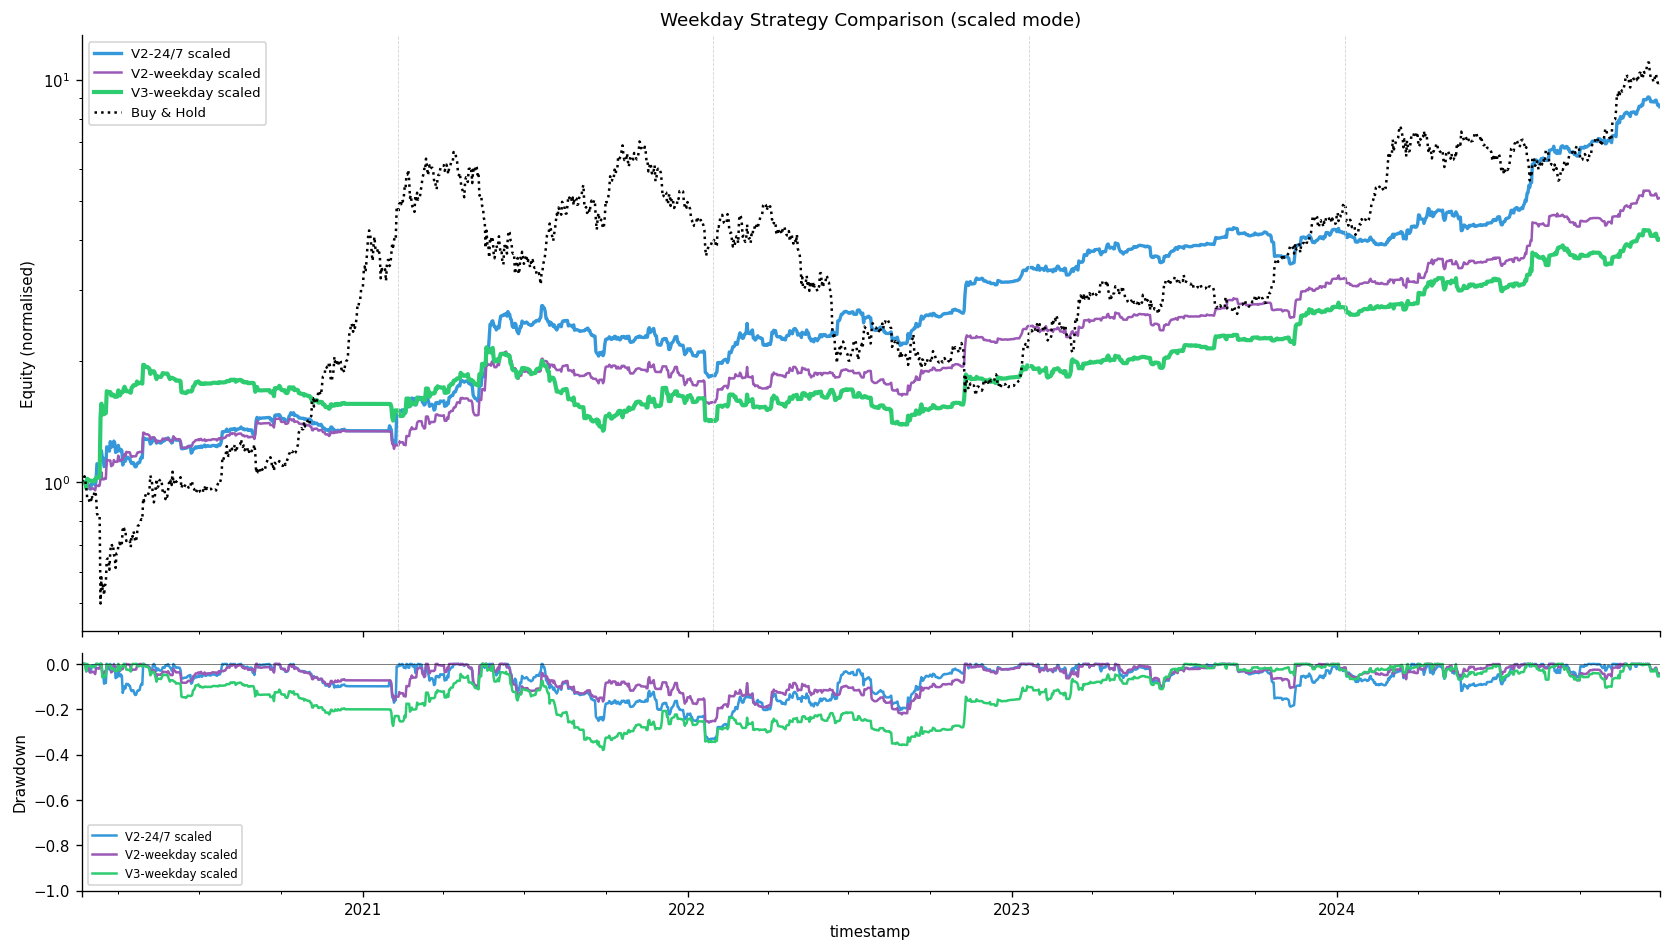

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.2]})

colors = {"V2-24/7 scaled": "#3498db", "V2-weekday scaled": "#9b59b6",
          "V3-weekday scaled": "#2ecc71", "Buy & Hold": "black"}

ax = axes[0]
for name, color in colors.items():
    lw = 2.5 if "V3" in name else (2.0 if "V2-24/7" in name else 1.5)
    ls = ":" if "Hold" in name else "-"
    strategies[name].plot(ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
for _, (tr, te) in enumerate(splits):
    ax.axvline(idx[te[0]], color="lightgray", linewidth=0.5, linestyle="--")
ax.set_title("Weekday Strategy Comparison (scaled mode)", fontsize=11)
ax.set_ylabel("Equity (normalised)")
ax.legend(fontsize=8)
ax.set_yscale("log")

ax2 = axes[1]
for name, color in colors.items():
    if "Hold" in name:
        continue
    eq = strategies[name]
    dd = (eq - eq.cummax()) / eq.cummax()
    dd.plot(ax=ax2, label=name, color=color, linewidth=1.5)
ax2.axhline(0, color="black", linewidth=0.3)
ax2.set_ylabel("Drawdown")
ax2.legend(fontsize=7)
ax2.set_ylim(-1.0, 0.05)

plt.tight_layout()
plt.show()

## §5 — Finding F22: Verdict

In [5]:
m_v2_247 = results["V2-24/7 scaled"]
m_v2_wd  = results["V2-weekday scaled"]
m_v3_wd  = results["V3-weekday scaled"]
m_bah    = results["Buy & Hold"]

print("=" * 78)
print("FINDING F22 — Weekday-Only Strategy (P-ML14)")
print("=" * 78)

print(f"""
THE THREE STRATEGIES (all scaled mode)
======================================
""")
print(f"{'Strategy':<25} {'Return':>10} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 55)
for name in ["V2-24/7 scaled", "V2-weekday scaled", "V3-weekday scaled", "Buy & Hold"]:
    m = results[name]
    print(f"  {name:<23} {m['total_return']*100:>+9.1f}%  {m['sharpe_ratio']:>+7.3f}  {m['max_drawdown']*100:>7.1f}%")

# Determine verdicts
v2wd_vs_v2_247 = m_v2_wd["sharpe_ratio"] - m_v2_247["sharpe_ratio"]
v3wd_vs_v2_247 = m_v3_wd["sharpe_ratio"] - m_v2_247["sharpe_ratio"]
v3wd_vs_v2_wd  = m_v3_wd["sharpe_ratio"] - m_v2_wd["sharpe_ratio"]

print(f"""
KEY COMPARISONS
===============
  Does going flat on weekends help? (V2-weekday vs V2-24/7)
    Sharpe delta: {v2wd_vs_v2_247:+.3f}  -> {'YES, weekday-only improves risk-adjusted return' if v2wd_vs_v2_247 > 0 else 'NO, weekend exposure helps'}

  Does V3 beat V2 on weekdays? (V3-weekday vs V2-weekday)
    Sharpe delta: {v3wd_vs_v2_wd:+.3f}  -> {'YES, cross-asset features add value on weekdays' if v3wd_vs_v2_wd > 0 else 'NO, V2 still wins even on weekdays only'}

  Does V3-weekday beat the 24/7 champion? (V3-weekday vs V2-24/7)
    Sharpe delta: {v3wd_vs_v2_247:+.3f}  -> {'YES — NEW CHAMPION' if v3wd_vs_v2_247 > 0 else 'NO — V2-24/7 remains champion'}

ECONOMIC INTERPRETATION
=======================
""")

if v2wd_vs_v2_247 > 0:
    print("  Weekend flat improves Sharpe: BTC weekend returns are noisy and largely")
    print("  unpredictable. By going flat, we avoid weekend whipsaws without giving up")
    print("  much expected return. This mirrors institutional practice: crypto desks")
    print("  reduce weekend exposure due to thin liquidity and no TradFi hedging.")
else:
    print("  Weekend exposure helps: despite thin liquidity, holding through weekends")
    print("  captures BTC's positive drift. The weekend return contribution to total")
    print("  return is significant enough to justify the additional volatility.")

if v3wd_vs_v2_wd > 0:
    print(f"\n  Cross-asset features work on weekdays: when TradFi markets are open and")
    print(f"  features are fresh, the institutional/liquidity/VIX channels provide")
    print(f"  genuine predictive value. The model uses SPY momentum and VIX stress to")
    print(f"  modulate crypto positioning in a way that BTC-only features cannot.")
else:
    print(f"\n  Cross-asset features still don't help even on weekdays only: the signal")
    print(f"  from SPY/VIX is too weak at daily frequency to overcome the noise from")
    print(f"  3 additional features in the LightGBM model.")

FINDING F22 — Weekday-Only Strategy (P-ML14)

THE THREE STRATEGIES (all scaled mode)

Strategy                      Return   Sharpe    MaxDD
-------------------------------------------------------
  V2-24/7 scaled             +758.7%   +1.583    -33.6%
  V2-weekday scaled          +408.7%   +1.454    -25.9%
  V3-weekday scaled          +302.3%   +1.036    -38.0%
  Buy & Hold                 +876.6%   +1.052    -76.6%

KEY COMPARISONS
  Does going flat on weekends help? (V2-weekday vs V2-24/7)
    Sharpe delta: -0.130  -> NO, weekend exposure helps

  Does V3 beat V2 on weekdays? (V3-weekday vs V2-weekday)
    Sharpe delta: -0.418  -> NO, V2 still wins even on weekdays only

  Does V3-weekday beat the 24/7 champion? (V3-weekday vs V2-24/7)
    Sharpe delta: -0.548  -> NO — V2-24/7 remains champion

ECONOMIC INTERPRETATION

  Weekend exposure helps: despite thin liquidity, holding through weekends
  captures BTC's positive drift. The weekend return contribution to total
  return is signi